In [133]:
import pybamm as pb
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import style
import numpy as np
import plotly as p
import math
import os
import timeit

print(pb.__version__)
style.use("ggplot")

25.8.0


In [134]:
model = pb.lithium_ion.DFN(
    {
        "particle phases": ("1", "1"),
        "open-circuit potential": ("single","single"),
        "cell geometry":"arbitrary",
        "intercalation kinetics":"symmetric Butler-Volmer",
        "diffusivity":"single",
        "thermal":"lumped",
        "contact resistance": "true",
    }
)
geometry=pb.battery_geometry(form_factor='cylindrical')

In [135]:
def graphite_LGM50_ocp_Chen2020(sto):
    """
    LG M50 Graphite open-circuit potential as a function of stoichiometry, fit taken
    from [1]. Prada2013 doesn't give an OCP for graphite, so we use this instead.

    References
    ----------
    .. [1] Chang-Hui Chen, Ferran Brosa Planella, Kieran O’Regan, Dominika Gastol, W.
    Dhammika Widanage, and Emma Kendrick. "Development of Experimental Techniques for
    Parameterization of Multi-scale Lithium-ion Battery Models." Journal of the
    Electrochemical Society 167 (2020): 080534.

    Parameters
    ----------
    sto: :class:`pybamm.Symbol`
        Electrode stoichiometry

    Returns
    -------
    :class:`pybamm.Symbol`
        Open-circuit potential
    """

    u_eq = (
        1.9793 * np.exp(-39.3631 * sto)
        + 0.2482
        - 0.0909 * np.tanh(29.8538 * (sto - 0.1234))
        - 0.04478 * np.tanh(14.9159 * (sto - 0.2769))
        - 0.0205 * np.tanh(30.4444 * (sto - 0.6103))
    )

    return u_eq


def graphite_LGM50_electrolyte_exchange_current_density_Chen2020(
    c_e, c_s_surf, c_s_max, T
):
    """
    Exchange-current density for Butler-Volmer reactions between graphite and LiPF6 in
    EC:DMC.

    References
    ----------
    .. [1] Chang-Hui Chen, Ferran Brosa Planella, Kieran O’Regan, Dominika Gastol, W.
    Dhammika Widanage, and Emma Kendrick. "Development of Experimental Techniques for
    Parameterization of Multi-scale Lithium-ion Battery Models." Journal of the
    Electrochemical Society 167 (2020): 080534.

    Parameters
    ----------
    c_e : :class:`pybamm.Symbol`
        Electrolyte concentration [mol.m-3]
    c_s_surf : :class:`pybamm.Symbol`
        Particle concentration [mol.m-3]
    c_s_max : :class:`pybamm.Symbol`
        Maximum particle concentration [mol.m-3]
    T : :class:`pybamm.Symbol`
        Temperature [K]

    Returns
    -------
    :class:`pybamm.Symbol`
        Exchange-current density [A.m-2]
    """
    m_ref = 2.48e-7  # (A/m2)(m3/mol)**1.5 - includes ref concentrations
    E_r = 35000
    arrhenius = np.exp(E_r / pb.constants.R * (1 / 298.15 - 1 / T))

    return m_ref * arrhenius * c_e**0.5 * c_s_surf**0.5 * (c_s_max - c_s_surf) ** 0.5


def LFP_ocp_Afshar2017(sto):
    """
    Open-circuit potential for LFP. Prada2013 doesn't give an OCP for LFP, so we use
    Afshar2017 instead.

    References
    ----------
    .. [1] Afshar, S., Morris, K., & Khajepour, A. (2017). Efficient electrochemical
    model for lithium-ion cells. arXiv preprint arXiv:1709.03970.

    Parameters
    ----------
    sto : :class:`pybamm.Symbol`
       stoichiometry of material (li-fraction)

    """

    c1 = -150 * sto
    c2 = -30 * (1 - sto)
    k = 3.40977 - 0.020269 * sto + 0.5 * np.exp(c1) - 0.9 * np.exp(c2)

    return k


def LFP_electrolyte_exchange_current_density_kashkooli2017(c_e, c_s_surf, c_s_max, T):
    """
    Exchange-current density for Butler-Volmer reactions between LFP and electrolyte

    References
    ----------
    .. [1] Kashkooli, A. G., Amirfazli, A., Farhad, S., Lee, D. U., Felicelli, S., Park,
    H. W., ... & Chen, Z. (2017). Representative volume element model of lithium-ion
    battery electrodes based on X-ray nano-tomography. Journal of Applied
    Electrochemistry, 47(3), 281-293.

    Parameters
    ----------
    c_e : :class:`pybamm.Symbol`
        Electrolyte concentration [mol.m-3]
    c_s_surf : :class:`pybamm.Symbol`
        Particle concentration [mol.m-3]
    c_s_max : :class:`pybamm.Symbol`
        Maximum particle concentration [mol.m-3]
    T : :class:`pybamm.Symbol`
        Temperature [K]

    Returns
    -------
    :class:`pybamm.Symbol`
        Exchange-current density [A.m-2]
    """

    m_ref = 2 * 10 ** (-7)  # (A/m2)(m3/mol)**1.5 - includes ref concentrations
    E_r = 39570
    arrhenius = np.exp(E_r / pb.constants.R * (1 / 298.15 - 1 / T))

    return m_ref * arrhenius * c_e**0.5 * c_s_surf**0.5 * (c_s_max - c_s_surf) ** 0.5


def electrolyte_conductivity_Prada2013(c_e, T):
    """
    Conductivity of LiPF6 in EC:EMC (3:7) as a function of ion concentration. The data
    comes from :footcite:`Prada2013`.

    Parameters
    ----------
    c_e: :class:`pybamm.Symbol`
        Dimensional electrolyte concentration
    T: :class:`pybamm.Symbol`
        Dimensional temperature

    Returns
    -------
    :class:`pybamm.Symbol`
        Solid conductivity
    """
    # convert c_e from mol/m3 to mol/L
    c_e = c_e / 1e6

    sigma_e = (
        4.1253e-4
        + 5.007 * c_e
        - 4721.2 * c_e**2
        + 1.5094e6 * c_e**3
        - 1.6018e8 * c_e**4
    ) * 1e3

    return sigma_e

def lfp_diffusivity(sto, T):
    
    D_ref = 0.5*2.3e-18
    E_D_s = 43000
    arrhenius = np.exp(E_D_s / pb.constants.R * (1 / 298.15 - 1 / T))

    return D_ref * arrhenius

def graphite_diffusivity(sto, T):
    
    D_ref = 0.5*4.8e-15
    E_D_s = 35000
    arrhenius = np.exp(E_D_s / pb.constants.R * (1 / 298.15 - 1 / T))

    return D_ref * arrhenius

In [136]:
LFP_param = {
        # cell
        "Negative current collector thickness [m]": 7.44e-05,
        "Negative electrode thickness [m]": 3.63e-05,
        "Separator thickness [m]": 2e-05,
        "Positive electrode thickness [m]": 6.25e-05,
        "Positive current collector thickness [m]": 5.75e-05,
        "Electrode height [m]": 1.713,
        "Electrode width [m]": 2*0.055,

        "Cell cooling surface area [m2]": 0.00533,
        "Cell volume [m3]": 3.46e-05,
        "Cell thermal expansion coefficient [m.K-1]": 1.1e-06,
        "Negative current collector conductivity [S.m-1]": 0.75*58411000.0,
        "Positive current collector conductivity [S.m-1]": 0.75*36914000.0,
        "Negative current collector density [kg.m-3]": 8960.0,
        "Positive current collector density [kg.m-3]": 2700.0,
        "Negative current collector specific heat capacity [J.kg-1.K-1]": 385.0,
        "Positive current collector specific heat capacity [J.kg-1.K-1]": 897.0,
        "Negative current collector thermal conductivity [W.m-1.K-1]": 401.0,
        "Positive current collector thermal conductivity [W.m-1.K-1]": 237.0,
        "Nominal cell capacity [A.h]": 2.5,
        "Current function [A]": 2.5,
        "Contact resistance [Ohm]": 0.006,   
        
        # Negative electrode
    
        "Maximum concentration in negative electrode [mol.m-3]": 30985,
        "Initial concentration in negative electrode [mol.m-3]": 0.76*30985, #8723
        "Negative electrode exchange-current density [A.m-2]": graphite_LGM50_electrolyte_exchange_current_density_Chen2020,
        "Negative electrode OCP [V]": graphite_LGM50_ocp_Chen2020,  #-0.01

        #"Negative electrode charge transfer coefficient": 0.5,
        #"Negative electrode double-layer capacity [F.m-2]": 0.2,
        
        "Negative particle radius [m]": 5.38e-07,
        "Negative particle diffusivity [m2.s-1]": graphite_diffusivity, 
        "Negative electrode active material volume fraction": 0.58, #685
        "Negative electrode porosity": 0.36, #294

        "Negative electrode Bruggeman coefficient (electrolyte)": 1.5,
        "Negative electrode Bruggeman coefficient (electrode)": 1.5,
        "Negative electrode conductivity [S.m-1]": 0.5*215.0,

        "Negative electrode density [kg.m-3]": 2260,
        "Negative electrode specific heat capacity [J.kg-1.K-1]": 700.0,
        "Negative electrode thermal conductivity [W.m-1.K-1]": 1.7,
        "Negative electrode OCP entropic change [V.K-1]": 0.0,
        
        # Positive electrode
        "Positive electrode OCP [V]": LFP_ocp_Afshar2017,
        "Maximum concentration in positive electrode [mol.m-3]": 22882,
        "Initial concentration in positive electrode [mol.m-3]": 0.01*22882,
    
        "Positive particle diffusivity [m2.s-1]": lfp_diffusivity, # 1.5X
        "Positive particle radius [m]": 0.75*3.80e-08,

        "Positive electrode conductivity [S.m-1]": 0.2*0.18,
        "Positive electrode active material volume fraction": 0.360529,
        "Positive electrode porosity": 0.55,
        "Positive electrode Bruggeman coefficient (electrolyte)": 1.5,  #1.5
        "Positive electrode Bruggeman coefficient (electrode)": 1.5,
    
        #"Positive electrode charge transfer coefficient": 0.5,
        #"Positive electrode double-layer capacity [F.m-2]": 0.2,
    
        "Positive electrode exchange-current density [A.m-2]": LFP_electrolyte_exchange_current_density_kashkooli2017,
        "Positive electrode density [kg.m-3]": 3610,
        "Positive electrode specific heat capacity [J.kg-1.K-1]": 700.0,
        "Positive electrode thermal conductivity [W.m-1.K-1]": 2.1,
        "Positive electrode OCP entropic change [V.K-1]": 0.0,
        
        # separator
        "Separator porosity": 0.45,
        "Separator Bruggeman coefficient (electrolyte)": 1.5,
        "Separator density [kg.m-3]": 397.0,
        "Separator specific heat capacity [J.kg-1.K-1]": 700.0,
        "Separator thermal conductivity [W.m-1.K-1]": 0.16,
        
        # electrolyte
        "Initial concentration in electrolyte [mol.m-3]": 1200.0,
        "Cation transference number": 0.38,
        "Thermodynamic factor": 1.0,
        "Electrolyte diffusivity [m2.s-1]": 0.5*2e-10,
        "Electrolyte conductivity [S.m-1]": electrolyte_conductivity_Prada2013,
        
        # experiment
        "Reference temperature [K]": 298.15,
        "Total heat transfer coefficient [W.m-2.K-1]": 12.0,
        "Ambient temperature [K]": 298.15,
        "Number of electrodes connected in parallel to make a cell": 1.0,
        "Number of cells connected in series to make a battery": 1.0,
        "Lower voltage cut-off [V]": 2,
        "Upper voltage cut-off [V]": 3.65,
        "Open-circuit voltage at 0% SOC [V]": 2,
        "Open-circuit voltage at 100% SOC [V]": 3.65,
        "Initial temperature [K]": 298.15,

        #electrode entropy change
    
        "Negative electrode OCP entropic change [V.K-1]": 0,
        "Positive electrode OCP entropic change [V.K-1]": 0.0,
    
}
param=pb.ParameterValues(LFP_param)

(1001,)
(1001,)
0.4977183557079577


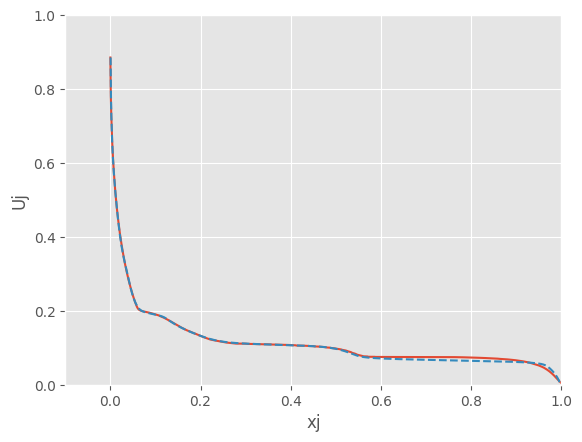

In [137]:
import numpy as np

df_gr=pd.read_excel(r"Hunan_interpolated.xlsx")

U_ocp = df_gr['U']
x_ocp = df_gr['x']

#gallery_window = np.array([0.05,0.1229,0.1388,0.1504,0.2993,0.3284,0.4161,3.5])  ## old gallery voltage marking
gallery_window = np.array([0,1.5])

U0    = np.array([0.9*0.07329586, 0.1081614,  0.1081655,  0.11370952, 0.19151176, 0.31958092, 0.44824024])
X     = np.array([0.3838419, 0.13241849, 0.09761792, 0.3040794,  0.04173912, 0.01555115, 0.03318803])
omega = np.array([0.09545492, 0.07039945, 0.17943078, 1.28833751, 0.13084723, 1.31652939, 4.08358201])

F, R, T = 96485.33212, 8.314462618, 298.15
f = F/(R*T)  # ~38.94 V^-1

def x_j(U, U0_j, X_j, omega_j, j):

    lo, hi = gallery_window[0], gallery_window[-1]
    mask = (U >= lo) & (U <= hi)
    if not np.any(mask):
        return out

    # Compute only on masked values to avoid unnecessary overflows
    z = (f*(U[mask] - U0_j))/omega_j
    inv1p_exp = 0.5*(1.0 - np.tanh(0.5*z))  # stable 1/(1+exp(z)); Uses stable logistic via tanh.
    out = X_j * inv1p_exp
    return out,mask

def x_total(U_ocp):
    U = np.asarray(U_ocp, dtype=float)
    x = np.zeros((len(U_ocp),7), dtype=float)
    #print(x.shape)

    for i in range(0,7):
        x[:,i],m = x_j(U, U0[i], X[i], omega[i], i)
        #plt.plot(x[:,i],U[m],label=f'{i+1}')
        #plt.legend()
        #plt.xlim([-0.01,0.5])
        #plt.ylim([0,1])
        plt.ylabel('Uj')
        plt.xlabel('xj')

    return x

y = x_total(U_ocp.to_numpy())
plt.plot(x_ocp,U_ocp)
x_gr = y.sum(axis=1)
print(x_gr.shape)
print(U_ocp.shape)
print(x_gr[500])
plt.plot(x_gr,U_ocp,'--')
plt.ylim([0,1])
plt.xlim([-0.1,1])

x_gr = np.asarray(x_gr)
U_gr = np.asarray(U_ocp)
param.update({
            "Negative electrode OCP [V]": ("Gr_OCP",[x_gr, U_gr]),
            })

In [138]:
# Simulation starts

experiment=pb.Experiment([
    (
    "Discharge at C/20 until 2 V",
    #"Rest for 10 minutes",
    #"Charge at C/12.5 until 3.6 V",
    #"Hold at 3.6 V until 1 mA",
    )

]*1
)
param=pb.ParameterValues(param)

solver = pb.IDAKLUSolver()
sim = pb.Simulation(model, parameter_values=param, experiment=experiment, solver=solver)
sol = sim.solve()

voltage=sol['Voltage [V]'].entries[0:]
time=sol['Time [s]'].entries[0:]
discharge_capacity=sol['Discharge capacity [A.h]'].entries[0:]
charge_capacity=sol['Throughput capacity [A.h]'].entries[0:]

soc=discharge_capacity/np.max(discharge_capacity)
print(f'{np.max(voltage):.4f} V')
print(f'{np.max(discharge_capacity):.4f} Ah')

3.4519 V
2.5033 Ah


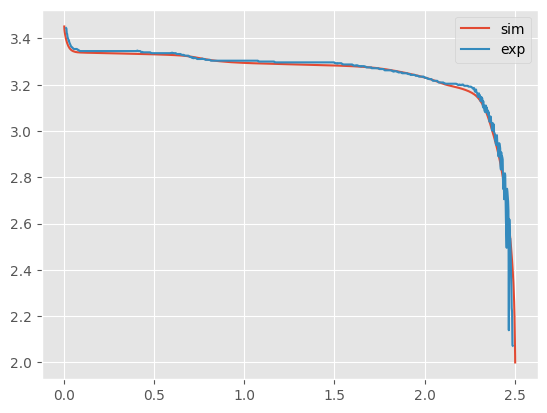

In [123]:
plt.plot(discharge_capacity,voltage, label='sim')
df= pd.read_excel('A123_data.xlsx',sheet_name = 'ocv')
#df2= pd.read_excel('A123_data.xlsx',sheet_name = '1D')
#df3= pd.read_excel('A123_data.xlsx',sheet_name = '1C')Z
plt.plot(df['Q']-0.01,df['V'], label='exp')
#plt.plot(df2['t'],df2['V'],color='blue')
#plt.plot(df3['t'],df3['V'],color='blue')
plt.legend()

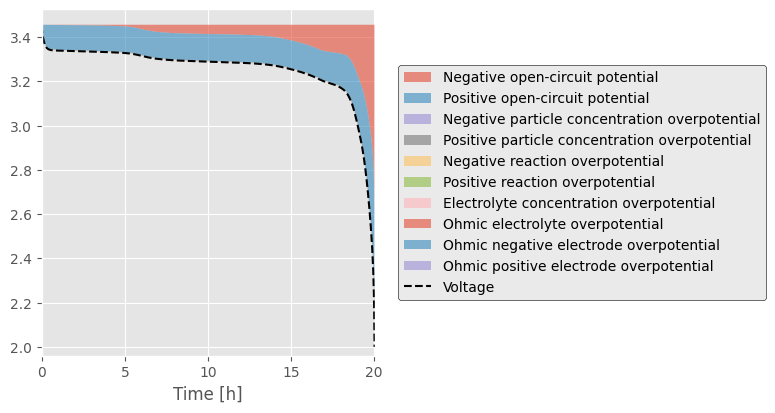

(<Figure size 800x400 with 1 Axes>, <Axes: xlabel='Time [h]'>)

In [119]:
sol.plot_voltage_components(split_by_electrode=True)

In [94]:
# Simulation starts

experiment=pb.Experiment([
    (
    "Discharge at 1C until 2.5 V",
    #"Rest for 10 minutes",
    "Charge at 1C until 3.6 V",
    "Hold at 3.6 V until 1 mA",
    )

]*1
)
param=pb.ParameterValues(param)

solver = pb.IDAKLUSolver()
sim = pb.Simulation(model, parameter_values=param, experiment=experiment, solver=solver)
sol = sim.solve()

voltage=sol['Voltage [V]'].entries[0:]
time=sol['Time [s]'].entries[0:]
discharge_capacity=sol['Discharge capacity [A.h]'].entries[0:]
charge_capacity=sol['Throughput capacity [A.h]'].entries[0:]

soc=discharge_capacity/np.max(discharge_capacity)
print(f'{np.max(voltage):.4f} V')
print(f'{np.max(discharge_capacity):.4f} Ah')

3.6000 V
2.4533 Ah


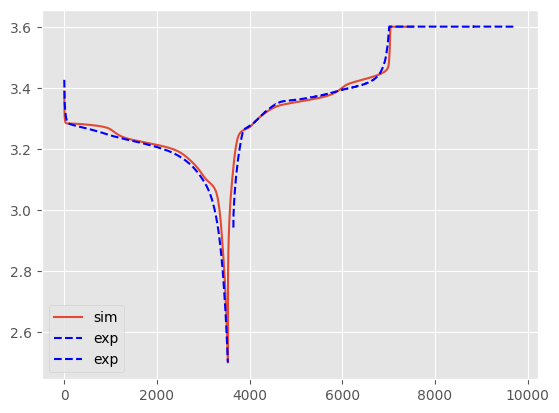

In [97]:
plt.plot(time,voltage,label='sim')
#df= pd.read_excel('A123_data.xlsx',sheet_name = 'ocv')
df2= pd.read_excel('A123_data.xlsx',sheet_name = '1D')
df3= pd.read_excel('A123_data.xlsx',sheet_name = '1C')
#plt.plot(df['ts'],df['V'])
plt.plot(df2['t'],df2['V'],color='blue',ls='--',label='exp')
plt.plot(df3['t']+3650,df3['V'],color='blue',ls='--',label='exp')
plt.legend()

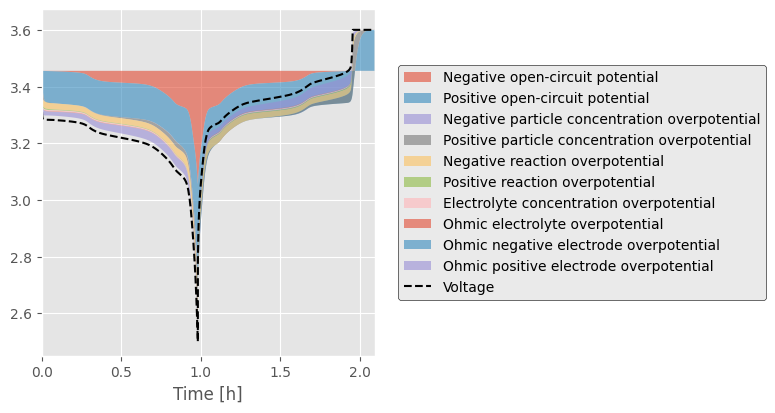

(<Figure size 800x400 with 1 Axes>, <Axes: xlabel='Time [h]'>)

In [98]:
sol.plot_voltage_components(split_by_electrode=True)

In [99]:
# After solving
Q_discharge = sol["Discharge capacity [A.h]"].entries[-1]
Q_charge = sol["Throughput capacity [A.h]"].entries[-1] - Q_discharge
print(f"Discharge capacity: {Q_discharge:.3f} Ah")
print(f"Charge capacity: {Q_charge:.3f} Ah")
# Compare with experimental 2.5 Ah


Discharge capacity: -0.014 Ah
Charge capacity: 4.935 Ah


In [100]:
charge_capacity=sol['Throughput capacity [A.h]'].entries[0:]

soc=discharge_capacity/np.max(discharge_capacity)
print(f'{np.max(voltage):.4f} V')
print(f'{np.max(discharge_capacity):.4f} Ah')

3.6000 V
2.4533 Ah


In [101]:
np.max(charge_capacity) - np.max(discharge_capacity)

2.4676779483934768

In [102]:
# Simulation starts

experiment=pb.Experiment([
    (
    "Discharge at 2C until 2 V",
    "Charge at 2C until 3.6 V",
    "Hold at 3.6 V until 2.2 mA",
    )

]*1
)
param=pb.ParameterValues(param)

solver = pb.IDAKLUSolver()
sim = pb.Simulation(model, parameter_values=param, experiment=experiment, solver=solver)
sol = sim.solve()

voltage=sol['Voltage [V]'].entries[0:]
time=sol['Time [s]'].entries[0:]
discharge_capacity=sol['Discharge capacity [A.h]'].entries[0:]
charge_capacity=sol['Throughput capacity [A.h]'].entries[0:]

soc=discharge_capacity/np.max(discharge_capacity)
print(f'{np.max(voltage):.4f} V')
print(f'{np.max(discharge_capacity):.4f} Ah')

3.6000 V
2.4857 Ah


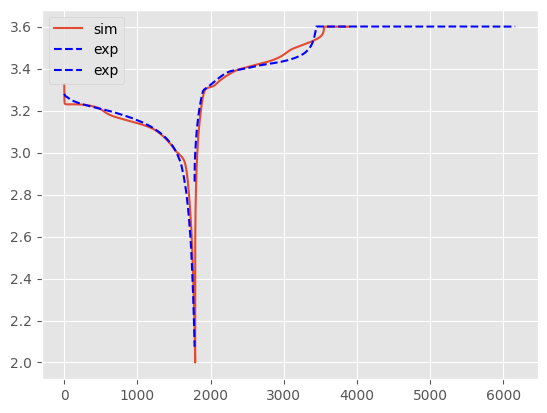

In [103]:
plt.plot(time,voltage,label='sim')
#df= pd.read_excel('A123_data.xlsx',sheet_name = 'ocv')
df2= pd.read_excel('A123_data.xlsx',sheet_name = '1D')
df3= pd.read_excel('A123_data.xlsx',sheet_name = '1C')
df4= pd.read_excel('A123_data.xlsx',sheet_name = '2D')
df5= pd.read_excel('A123_data.xlsx',sheet_name = '2C')
#plt.plot(df['ts'],df['V'])
plt.plot(df4['t'],df4['V'],color='blue',ls='--',label='exp')
plt.plot(df5['t']+1782,df5['V'],color='blue',ls='--',label='exp')
plt.legend()

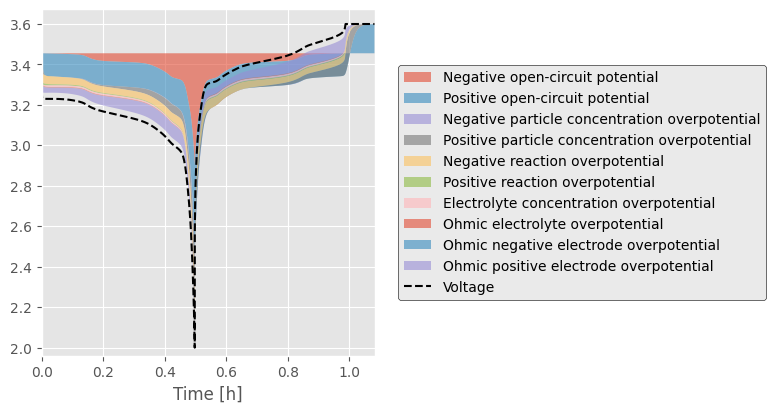

(<Figure size 800x400 with 1 Axes>, <Axes: xlabel='Time [h]'>)

In [104]:
sol.plot_voltage_components(split_by_electrode=True)

In [130]:
# Simulation starts

experiment=pb.Experiment([
    (
    "Charge at 3C until 3.6 V",
    "Hold at 3.6 V until 0.001 A",
    )

]*1
)
param=pb.ParameterValues(param)

model_local = model.set_initial_conditions_from(sol, inplace=True)

solver = pb.IDAKLUSolver()
sim = pb.Simulation(model_local, parameter_values=param, experiment=experiment, solver=solver)
sol = sim.solve()

voltage=sol['Voltage [V]'].entries[0:]
time=sol['Time [s]'].entries[0:]
discharge_capacity=sol['Discharge capacity [A.h]'].entries[0:]
charge_capacity=sol['Throughput capacity [A.h]'].entries[0:]

soc=discharge_capacity/np.max(discharge_capacity)
print(f'{np.max(voltage):.4f} V')
print(f'{np.max(discharge_capacity):.4f} Ah')

3.6000 V
2.5033 Ah


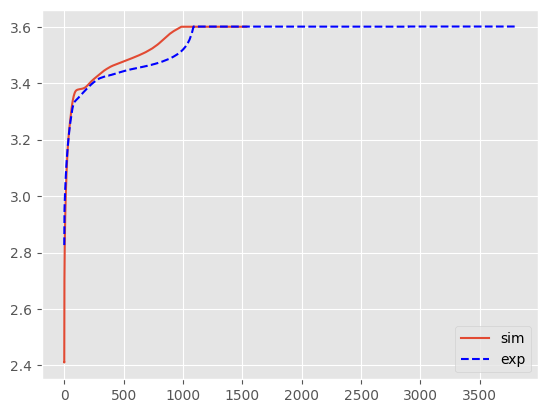

In [131]:
plt.plot(time,voltage,label='sim')
#df= pd.read_excel('A123_data.xlsx',sheet_name = 'ocv')
df2= pd.read_excel('A123_data.xlsx',sheet_name = '1D')
df3= pd.read_excel('A123_data.xlsx',sheet_name = '1C')
df4= pd.read_excel('A123_data.xlsx',sheet_name = '2C')
df5= pd.read_excel('A123_data.xlsx',sheet_name = '3C')
#plt.plot(df['ts'],df['V'])
plt.plot(df5['t'],df5['V'],color='blue',ls='--',label='exp')
plt.legend()

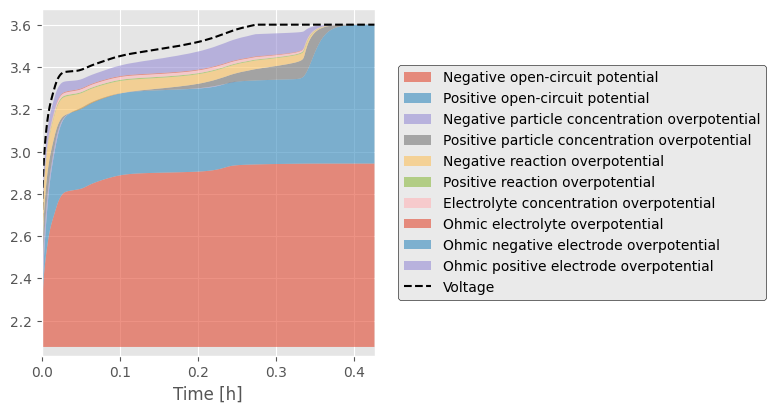

(<Figure size 800x400 with 1 Axes>, <Axes: xlabel='Time [h]'>)

In [132]:
sol.plot_voltage_components(split_by_electrode=True)

In [139]:
# Simulation starts

experiment=pb.Experiment([
    (
    "Charge at 4C until 3.6 V",
    "Hold at 3.6 V until 0.001 A",
    )

]*1
)
param=pb.ParameterValues(param)

model_local = model.set_initial_conditions_from(sol, inplace=True)

solver = pb.IDAKLUSolver()
sim = pb.Simulation(model_local, parameter_values=param, experiment=experiment, solver=solver)
sol = sim.solve()

voltage=sol['Voltage [V]'].entries[0:]
time=sol['Time [s]'].entries[0:]
discharge_capacity=sol['Discharge capacity [A.h]'].entries[0:]
charge_capacity=sol['Throughput capacity [A.h]'].entries[0:]

soc=discharge_capacity/np.max(discharge_capacity)
print(f'{np.max(voltage):.4f} V')
print(f'{np.max(discharge_capacity):.4f} Ah')

3.6000 V
2.5033 Ah


(0.0, 2000.0)

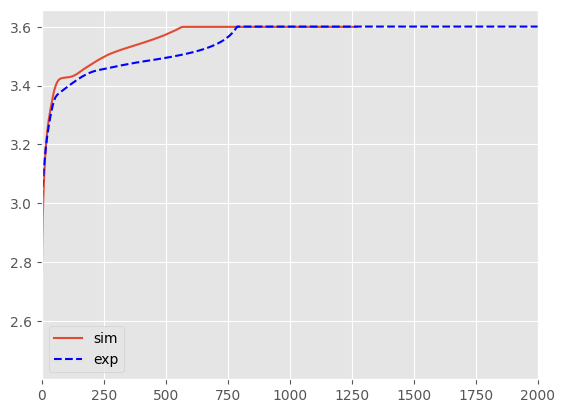

In [140]:
plt.plot(time,voltage,label='sim')
#df= pd.read_excel('A123_data.xlsx',sheet_name = 'ocv')
df2= pd.read_excel('A123_data.xlsx',sheet_name = '1D')
df3= pd.read_excel('A123_data.xlsx',sheet_name = '1C')
df4= pd.read_excel('A123_data.xlsx',sheet_name = '2C')
df5= pd.read_excel('A123_data.xlsx',sheet_name = '3C')
df6= pd.read_excel('A123_data.xlsx',sheet_name = '4C')
#plt.plot(df['ts'],df['V'])
plt.plot(df6['t'],df6['V'],color='blue',ls='--',label='exp')
plt.legend()
plt.xlim([0,2000])

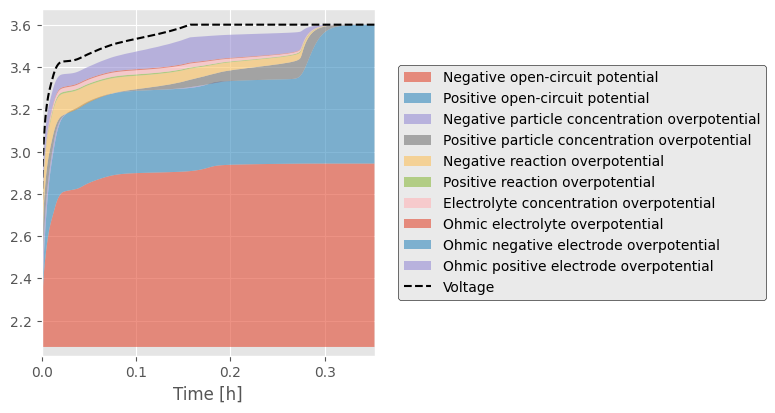

(<Figure size 800x400 with 1 Axes>, <Axes: xlabel='Time [h]'>)

In [141]:
sol.plot_voltage_components(split_by_electrode=True)